In [139]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
)

from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression


In [123]:
pip install catboost lightgbm xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.1 MB/s eta 0:00:00


In [91]:
df = pd.read_csv("Starship_Safety.csv")
df.head()

,f1_hex_code,f2_temp_log,f3_wave_phase,f4_micro_metric,f5_sector_class,f6_launch_date,f7_power_skew,f8_bimodal_core,f9_cargo_path,f10_status_mix,f11_sync_clock,f12_spatial_coord,f13_noisy_base,f14_crew_code,f15_parity_bit,target_breach
0,0xca,Temp: 25.69 C,66.754990,30.682205,Delta,2026-01-01,14.897535,-19.983774,B-C-A-B,F,38605.0,"(14, 5)",207.0,ieeyiayo,177.0,0
1,0x217,Temp: 27.50 C,9.553531,35.009400,Beta,2026-01-02,3.871631,20.316178,B-C-B-C-A,TRUE,59616.0,"(17, 6)",404.0,zueiaeae,195.0,1
2,0x3c0,Temp: 46.17 C,62.385932,81.509964,Gamma,2026-01-03,34.830067,19.444911,A-B-D-C,T,64479.0,"(16, 11)",417.0,iaiaeuzz,922.0,1
3,0x172,Temp: 23.93 C,45.176768,92.701297,Delta,2026-01-04,0.029184,22.582548,B-D,0,90934.0,"(10, 15)",295.0,uzyooyyx,13.0,1
4,0xce,Temp: 30.56 C,58.660846,46.054140,Delta,2026-01-05,148.661563,-20.843560,A-B,1,50883.0,"(7, 2)",761.0,iaoeyzua,876.0,0


In [92]:
df.shape

(1000, 16)

In [93]:
df.describe()

,f3_wave_phase,f4_micro_metric,f7_power_skew,f8_bimodal_core,f11_sync_clock,f13_noisy_base,f15_parity_bit
count,998.000000,998.000000,998.000000,998.000000,999.000000,999.000000,998.000000
mean,49.833923,54.222814,71.714402,-0.011687,54819.540541,499.518519,524.769539
std,28.809858,25.707701,716.064682,20.072703,27032.827988,257.753792,450.170623
min,0.156511,10.001035,0.000121,-26.225820,10005.000000,60.000000,2.000000
25%,25.513548,32.105651,0.112911,-19.913578,30112.000000,287.000000,241.250000
50%,50.565391,54.544710,0.995937,-14.701437,55344.000000,501.000000,505.000000
75%,74.519882,76.102473,7.292835,20.024900,79273.000000,723.000000,782.000000
max,99.834751,98.901442,16802.431860,26.153721,99987.000000,939.000000,6545.000000


In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   f1_hex_code        1000 non-null   object 
 1   f2_temp_log        997 non-null    object 
 2   f3_wave_phase      998 non-null    float64
 3   f4_micro_metric    998 non-null    float64
 4   f5_sector_class    999 non-null    object 
 5   f6_launch_date     999 non-null    object 
 6   f7_power_skew      998 non-null    float64
 7   f8_bimodal_core    998 non-null    float64
 8   f9_cargo_path      1000 non-null   object 
 9   f10_status_mix     1000 non-null   object 
 10  f11_sync_clock     999 non-null    float64
 11  f12_spatial_coord  1000 non-null   object 
 12  f13_noisy_base     999 non-null    float64
 13  f14_crew_code      999 non-null    object 
 14  f15_parity_bit     998 non-null    float64
 15  target_breach      1000 non-null   object 
dtypes: float64(7), object(9)


In [95]:
df.describe(include='all')

,f1_hex_code,f2_temp_log,f3_wave_phase,f4_micro_metric,f5_sector_class,f6_launch_date,f7_power_skew,f8_bimodal_core,f9_cargo_path,f10_status_mix,f11_sync_clock,f12_spatial_coord,f13_noisy_base,f14_crew_code,f15_parity_bit,target_breach
count,1000,997,998.000000,998.000000,999,999,998.000000,998.000000,1000,1000,999.000000,1000,999.000000,999,998.000000,1000
unique,585,880,NaN,NaN,4,999,NaN,NaN,409,6,NaN,339,NaN,999,NaN,5
top,0xc6,Temp: 17.28 C,NaN,NaN,Gamma,2028-09-26,NaN,NaN,A,FALSE,NaN,"(7, 9)",NaN,zxyuzaza,NaN,0
freq,8,3,NaN,NaN,261,1,NaN,NaN,63,180,NaN,10,NaN,1,NaN,497
mean,NaN,NaN,49.833923,54.222814,NaN,NaN,71.714402,-0.011687,NaN,NaN,54819.540541,NaN,499.518519,NaN,524.769539,NaN
std,NaN,NaN,28.809858,25.707701,NaN,NaN,716.064682,20.072703,NaN,NaN,27032.827988,NaN,257.753792,NaN,450.170623,NaN
min,NaN,NaN,0.156511,10.001035,NaN,NaN,0.000121,-26.225820,NaN,NaN,10005.000000,NaN,60.000000,NaN,2.000000,NaN
25%,NaN,NaN,25.513548,32.105651,NaN,NaN,0.112911,-19.913578,NaN,NaN,30112.000000,NaN,287.000000,NaN,241.250000,NaN
50%,NaN,NaN,50.565391,54.544710,NaN,NaN,0.995937,-14.701437,NaN,NaN,55344.000000,NaN,501.000000,NaN,505.000000,NaN
75%,NaN,NaN,74.519882,76.102473,NaN,NaN,7.292835,20.024900,NaN,NaN,79273.000000,NaN,723.000000,NaN,782.000000,NaN


In [96]:
df.isnull().sum()

,0
f1_hex_code,0
f2_temp_log,3
f3_wave_phase,2
f4_micro_metric,2
f5_sector_class,1
f6_launch_date,1
f7_power_skew,2
f8_bimodal_core,2
f9_cargo_path,0
f10_status_mix,0


In [97]:
df.duplicated().sum()

np.int64(0)

<Axes: xlabel='target_breach'>

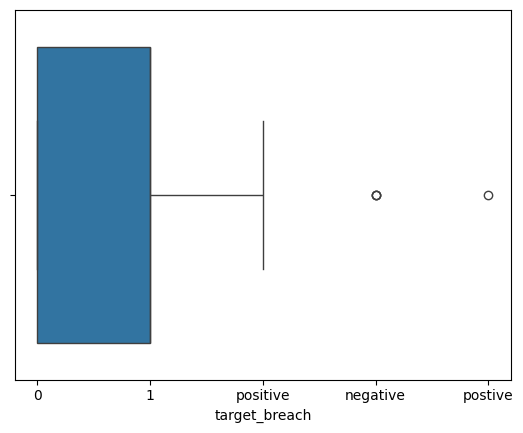

In [98]:
sns.boxplot(data = df, x='target_breach')

<Axes: xlabel='target_breach', ylabel='count'>

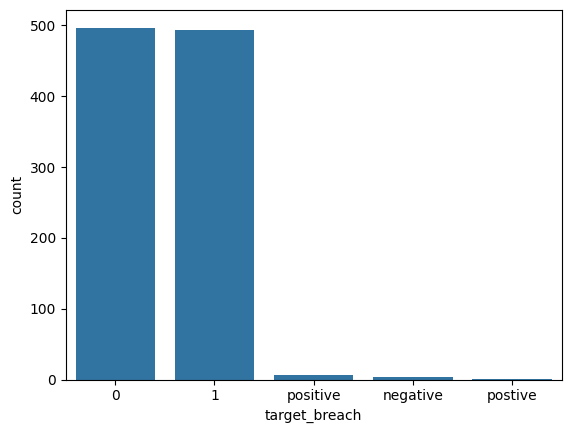

In [99]:
sns.countplot(x=df['target_breach'])

In [100]:
df['target_breach'].value_counts()

,count
target_breach,
0,497
1,493
positive,6
negative,3
postive,1


In [101]:
df['target_breach'].value_counts(normalize=True)

,proportion
target_breach,
0,0.497
1,0.493
positive,0.006
negative,0.003
postive,0.001


## **Feature Engineering**

---




## Hex Code → Integer

In [102]:
df['f1_hex_code'] = df['f1_hex_code'].apply(lambda x: int(str(x), 16))

## Temperature Extract

In [103]:
df['f2_temp_log'] = (
    df['f2_temp_log'].str.extract(r'([-+]?\d*\.?\d+)').astype(float)
)

## Launch Date

In [104]:
df["f6_launch_date"] = pd.to_datetime(df["f6_launch_date"])

df["launch_year"] = df["f6_launch_date"].dt.year
df["launch_month"] = df["f6_launch_date"].dt.month
df["launch_day"] = df["f6_launch_date"].dt.day

df.drop("f6_launch_date",axis=1,inplace=True)

## Coordinate Feature

In [105]:
coord = df["f12_spatial_coord"].str.extract(r'([-0-9.]+), ([-0-9.]+)')

df["coord_x"] = coord[0].astype(float)
df["coord_y"] = coord[1].astype(float)

df.drop("f12_spatial_coord", axis=1, inplace=True)

In [106]:
df.head()

,f1_hex_code,f2_temp_log,f3_wave_phase,f4_micro_metric,f5_sector_class,f7_power_skew,f8_bimodal_core,f9_cargo_path,f10_status_mix,f11_sync_clock,f13_noisy_base,f14_crew_code,f15_parity_bit,target_breach,launch_year,launch_month,launch_day,coord_x,coord_y
0,202,25.69,66.754990,30.682205,Delta,14.897535,-19.983774,B-C-A-B,F,38605.0,207.0,ieeyiayo,177.0,0,2026.0,1.0,1.0,14.0,5.0
1,535,27.50,9.553531,35.009400,Beta,3.871631,20.316178,B-C-B-C-A,TRUE,59616.0,404.0,zueiaeae,195.0,1,2026.0,1.0,2.0,17.0,6.0
2,960,46.17,62.385932,81.509964,Gamma,34.830067,19.444911,A-B-D-C,T,64479.0,417.0,iaiaeuzz,922.0,1,2026.0,1.0,3.0,16.0,11.0
3,370,23.93,45.176768,92.701297,Delta,0.029184,22.582548,B-D,0,90934.0,295.0,uzyooyyx,13.0,1,2026.0,1.0,4.0,10.0,15.0
4,206,30.56,58.660846,46.054140,Delta,148.661563,-20.843560,A-B,1,50883.0,761.0,iaoeyzua,876.0,0,2026.0,1.0,5.0,7.0,2.0


In [107]:
df["target_breach"] = (
    df["target_breach"]
    .replace({
        "positive": 1,
        "postive": 1,
        "negative": 0
    })
    .astype(int)
)

## Separate X and y

In [109]:
X = df.drop("target_breach", axis=1)
y = df["target_breach"]

## Detect Categorical Columns

In [110]:
cat_cols = X.select_dtypes(
    include="object"
).columns

cat_cols

Index(['f5_sector_class', 'f9_cargo_path', 'f10_status_mix', 'f14_crew_code'], dtype='object')

In [111]:
num_cols = X.select_dtypes(
    exclude="object"
).columns

num_cols

Index(['f1_hex_code', 'f2_temp_log', 'f3_wave_phase', 'f4_micro_metric',
       'f7_power_skew', 'f8_bimodal_core', 'f11_sync_clock', 'f13_noisy_base',
       'f15_parity_bit', 'launch_year', 'launch_month', 'launch_day',
       'coord_x', 'coord_y'],
      dtype='object')

## Preprocessing

In [112]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [113]:
preprocessor = ColumnTransformer([
    ("num",numeric_transformer,num_cols),
    ("cat",categorical_transformer,cat_cols)
])

## Train Test Split

In [114]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [117]:
# LogisticRegression

lr_pipe = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LogisticRegression())
    ]
)

lr_pipe.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['f1_hex_code', 'f2_temp_log', 'f3_wave_phase', 'f4_micro_metric',
       'f7_power_skew', 'f8_bimodal_core', 'f11_sync_clock', 'f13_noisy_base',
       'f15_parity_bit', 'launch_year', 'launch_month', 'launch_day',
       'coord_x', 'coord_y'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['f5_sector_class', 'f9_cargo_path', 'f10_status_mix', 'f14_crew_code'], dtype='object'))])),
                ('model', LogisticRegression())])

In [118]:
y_pred = lr_pipe.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

0.575


In [121]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.58      0.57      0.57       100
           1       0.57      0.58      0.58       100

    accuracy                           0.57       200
   macro avg       0.58      0.57      0.57       200
weighted avg       0.58      0.57      0.57       200



In [128]:
# model : CatBoost

cat_model = Pipeline(
    steps=[
        ("prep", preprocessor),
        ("model", CatBoostClassifier(
            verbose=0,
            random_state=42
        ))
    ]
)

cat_model.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['f1_hex_code', 'f2_temp_log', 'f3_wave_phase', 'f4_micro_metric',
       'f7_power_skew', 'f8_bimodal_core', 'f11_sync_clock', 'f13_noisy_base',
       'f15_parity_bit', 'launch_year', 'launch_month', 'launch_day',
       'coord_x', 'coord_y'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['f5_sector_class', 'f9_cargo_path', 'f10_status_mix', 'f14_crew_code'], dtype='object'))])),
                ('model', CatBoostClassifier(random_state=42, verbose=0))])

In [130]:
pred = cat_model.predict(X_test)

In [131]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.69      0.71      0.70       100
           1       0.70      0.68      0.69       100

    accuracy                           0.69       200
   macro avg       0.70      0.70      0.69       200
weighted avg       0.70      0.69      0.69       200



In [133]:
print("Accuracy :",accuracy_score(y_test,pred))
print("F1 :",f1_score(y_test,pred))
print("ROC :",roc_auc_score(y_test,pred))

Accuracy : 0.695
F1 : 0.6903553299492385
ROC : 0.6950000000000001


In [134]:
# model : LightGBM

lgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LGBMClassifier(
            random_state = 42
        ))
    ]
)

lgb_model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 400, number of negative: 400
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000390 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2396
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits wit

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['f1_hex_code', 'f2_temp_log', 'f3_wave_phase', 'f4_micro_metric',
       'f7_power_skew', 'f8_bimodal_core', 'f11_sync_clock', 'f13_noisy_base',
       'f15_parity_bit', 'launch_year', 'launch_month', 'launch_day',
       'coord_x', 'coord_y'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['f5_sector_class', 'f9_cargo_path', 'f10_status_mix', 'f14_crew_code'], dtype='object'))])),
                ('model', LGBMClassifier(random_state=42))])

In [135]:
lgb_pred = lgb_model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.58      0.57      0.57       100
           1       0.57      0.58      0.58       100

    accuracy                           0.57       200
   macro avg       0.58      0.57      0.57       200
weighted avg       0.58      0.57      0.57       200



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [137]:
# model : XGBoost

xgb_model = Pipeline([
    ("prep",preprocessor),
    ("model",XGBClassifier(
        eval_metric="logloss",
        random_state=42
    ))
])

xgb_model.fit(X_train,y_train)

pred = xgb_model.predict(X_test)

print("Accuracy :",accuracy_score(y_test,pred))
print("F1 :",f1_score(y_test,pred))

Accuracy : 0.68
F1 : 0.6595744680851063


## Cross Validation

In [141]:
skf = StratifiedKFold(
    n_splits= 5,
    shuffle=True,
    random_state=42
)

score = cross_val_score(
    cat_model,
    X,
    y,
    cv = skf,
    scoring = "f1"
)

print(score)
print(score.mean())

[0.68062827 0.7106599  0.74626866 0.77486911 0.72081218]
0.726647624026729


## Train Final Model

In [142]:
cat_model.fit(X, y)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['f1_hex_code', 'f2_temp_log', 'f3_wave_phase', 'f4_micro_metric',
       'f7_power_skew', 'f8_bimodal_core', 'f11_sync_clock', 'f13_noisy_base',
       'f15_parity_bit', 'launch_year', 'launch_month', 'launch_day',
       'coord_x', 'coord_y'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['f5_sector_class', 'f9_cargo_path', 'f10_status_mix', 'f14_crew_code'], dtype='object'))])),
                ('model', CatBoostClassifier(random_state=42, verbose=0))])

In [146]:
prediction = cat_model.predict(X_test)
print(prediction)

[1 0 1 0 1 1 1 1 0 0 1 1 1 0 0 0 1 0 1 0 1 0 1 0 1 1 1 1 0 1 0 1 1 1 1 0 0
 0 0 0 0 1 1 0 0 1 0 1 1 0 1 0 1 0 0 0 1 0 0 1 1 1 1 0 0 0 1 1 0 0 0 0 1 1
 1 1 0 0 1 0 0 1 1 1 1 0 0 0 0 0 1 1 1 1 0 1 1 0 1 0 1 0 0 1 1 1 0 1 0 1 1
 1 0 1 0 0 1 1 0 0 0 1 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 1 0 0 1
 1 0 0 0 1 1 0 0 1 1 0 0 1 0 1 0 1 1 1 0 0 0 0 0 1 0 1 1 0 0 0 1 1 0 1 0 1
 1 1 1 1 1 0 1 1 1 1 1 1 0 1 1]


## Submission

In [147]:
submission = pd.DataFrame({
    "target_breach" : prediction
})

submission.to_csv("submission.csv", index=False)